## **Título**: Ajuste fino a T5 para resúmenes

## **Alumno**: Josep Gabriel Fornes Reynes

# Introducción

Durante el desarrollo de la asignatura, hemos explorado el ajuste fino (*fine-tuning*) en distintas arquitecturas de Modelos de Lenguaje:
- **Arquitectura Encoder-only**: utilizamos el modelo **BERT** junto con el dataset *Yelp review* para tareas de **clasificación de texto** (análisis de sentimiento).
- **Arquitectura Decoder-only**: trabajamos con el modelo **Llama-2** aplicando la técnica **QLoRA** sobre el dataset *Guanaco* para la generación de texto conversacional.

Para complementar estas experiencias y cubrir el espectro completo de arquitecturas Transformer, este proyecto se centra en una arquitectura **Encoder-Decoder** (Seq2Seq). Esta arquitectura es ideal para tareas donde la entrada y la salida son secuencias de texto de longitud variable, como la traducción o el resumen.
El objetivo principal de este trabajo es realizar un resumen abstractivo de noticias. Para ello, he seleccionado el modelo **T5-small** (*Text-to-Text Transfer Transformer*) y el dataset **CNN/DailyMail**. Esta tarea presenta un desafío interesante de evaluación, ya que no se mide por exactitud (*accuracy*), sino mediante métricas de similitud de n-gramas como **ROUGE**, lo que permite analizar la capacidad del modelo para comprender y reescribir información compleja."

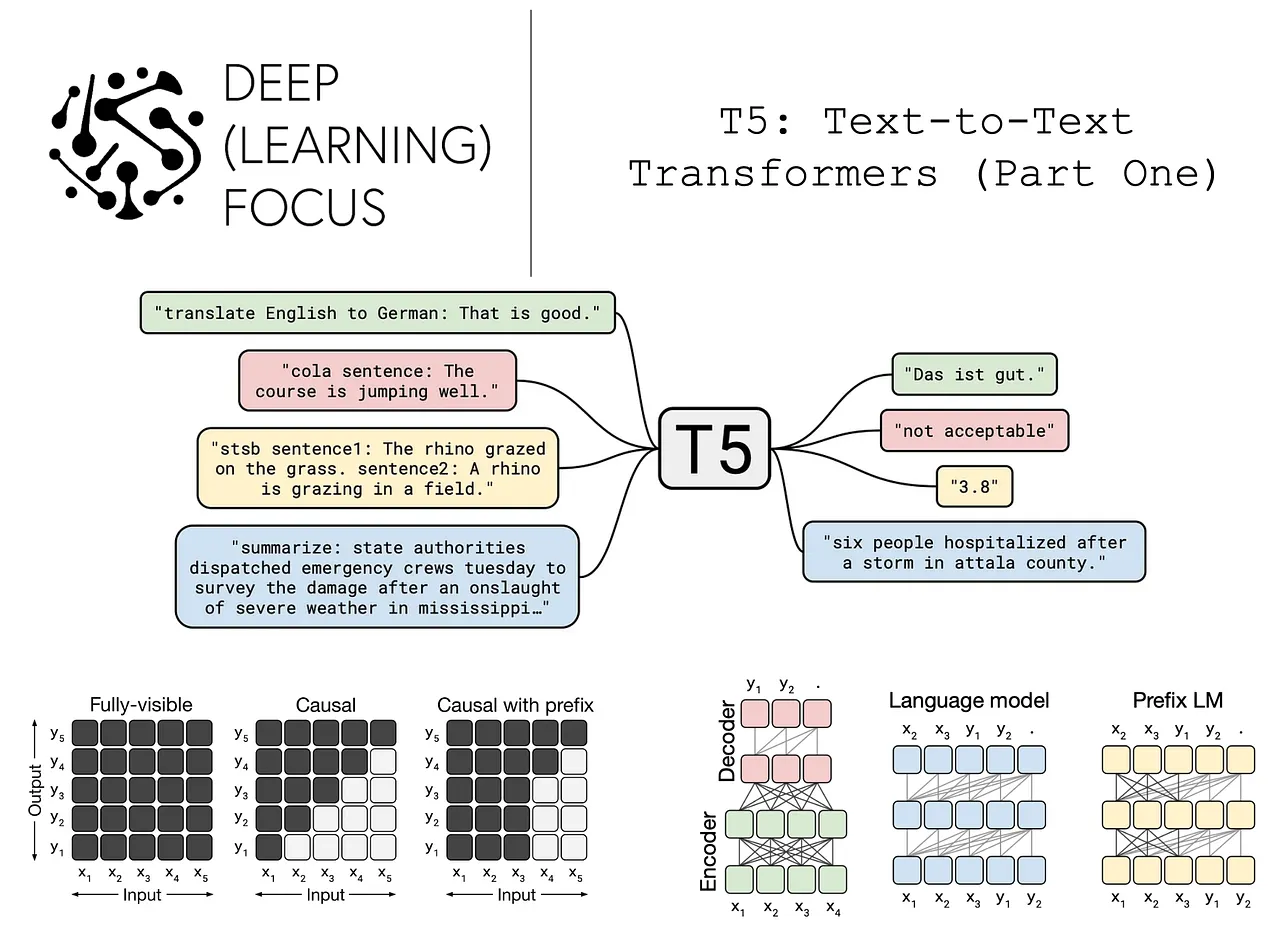

(Imágen obtenida desde [Deep (Learning) Focus](https://cameronrwolfe.substack.com/p/t5-text-to-text-transformers-part))

# Dataset

## Instalaciones necesarias

Para llevar a cabo el ajuste fino, utilizaremos el ecosistema de bibliotecas de **Hugging Face**, que se ha convertido en el estándar de la industria para NLP moderno. Las principales librerías son:
- `transformers`: El núcleo del proyecto. Nos proporciona la arquitectura del modelo T5 preentrenado y su tokenizador asociado.
- `datasets`: Fundamental para descargar y gestionar eficientemente el dataset CNN/DailyMail sin saturar la memoria RAM (gracias a su sistema de mapeo en memoria).
- `accelerate`: Optimiza el bucle de entrenamiento para que funcione de manera eficiente en la GPU T4 de Google Colab, gestionando el movimiento de tensores automáticamente.
- `evaluate`: La utilizaremos para cargar las métricas de evaluación del modelo.
- `rouge_score`: Una dependencia específica necesaria para calcular la métrica ROUGE (Recall-Oriented Understudy for Gisting Evaluation), que es el estándar académico para evaluar la calidad de los resúmenes automáticos.

In [1]:
!pip install -q transformers datasets accelerate evaluate rouge_score

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.7 MB/s eta 0:00:00


In [2]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, DataCollatorForSeq2Seq, Seq2SeqTrainingArguments, Seq2SeqTrainer
from datasets import load_dataset
import evaluate
import numpy as np
import torch
import matplotlib.pyplot as plt

Miramos si tenemos la GPU operativa

In [4]:
if torch.cuda.is_available():
    print(f"GPU detectada: {torch.cuda.get_device_name(0)}")
else:
    print("No se ha detectado GPU.")

GPU detectada: Tesla T4


## Selección del dataset

Para el desarrollo de este proyecto, se ha utilizado el dataset **CNN/DailyMail** (versión 3.0.0), un estándar de referencia en la comunidad de NLP para tareas de resumen abstractivo. Este conjunto de datos, consta de noticias reales en inglés emparejadas con resúmenes escritos por humanos.

In [5]:
# Cargar el dataset
dataset = load_dataset("cnn_dailymail", "3.0.0")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

3.0.0/train-00000-of-00003.parquet:   0%|          | 0.00/257M [00:00<?, ?B/s]

3.0.0/train-00001-of-00003.parquet:   0%|          | 0.00/257M [00:00<?, ?B/s]

3.0.0/train-00002-of-00003.parquet:   0%|          | 0.00/259M [00:00<?, ?B/s]

3.0.0/validation-00000-of-00001.parquet:   0%|          | 0.00/34.7M [00:00<?, ?B/s]

3.0.0/test-00000-of-00001.parquet:   0%|          | 0.00/30.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/287113 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/13368 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/11490 [00:00<?, ? examples/s]

## Estructura de datos

Cada ejemplo del dataset contiene tres campos principales:

- `id`: Un identificador único para el artículo.

- `article`: El cuerpo del texto de la noticia (nuestra secuencia de entrada o Input).

- `highlights`: El resumen de referencia generado por humanos (nuestra secuencia objetivo).

In [6]:
# Ver la estructura de un ejemplo
print(dataset["test"][0].keys())

dict_keys(['article', 'highlights', 'id'])


## Preprocesamiento de datos

Para transformar los textos en secuencias numéricas comprensibles por el modelo, cargamos el tokenizador asociado al checkpoint `t5-small` utilizando la clase `AutoTokenizer` de la librería Transformers.

In [7]:
# Nombre del modelo
model_checkpoint = "t5-small"

tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

tokenizer_config.json:   0%|          | 0.00/2.32k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

Configuramos el tokenizador para utilizar el padding a la izquierda, modificando el comportamiento por defecto del modelo para adaptarlo mejor a la generación de secuencias en lotes.

In [8]:
tokenizer.padding_side = "left"

Definimos la función para procesar los ejemplos del dataset, la cual implementa tres pasos críticos:
1. **Prefijo de tarea**: se añade la cadena `"summarize: "` al inicio de cada artículo. Esto es fundamental para **T5**, ya que al ser un modelo entrenado en múltiples tareas (traducción, corrección, etc.), necesita este *prompt* para activar su capacidad de resumen.

2. **Gestión de longitudes**:
- **Entradas (artículos)**: Se establece una longitud máxima de 1024 tokens. Cualquier texto que exceda esta longitud se trunca, asegurando que la entrada quepa en la memoria de la GPU.

- **Salidas (resúmenes)**: Se establece una longitud máxima de 128 tokens para los resúmenes objetivo, ya que estos textos son naturalmente más breves.

In [9]:
def tokenize_function(examples):
    # Prefijo de tarea
    inputs = ["summarize: " + doc for doc in examples["article"]]

    # Gestión de longitudes
    model_inputs = tokenizer(inputs, max_length=1024, truncation=True)
    labels = tokenizer(text_target=examples["highlights"], max_length=128, truncation=True)

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

El dataset completo contiene más de 300.000 pares de noticias y resúmenes.

In [10]:
print(f"Ejemplos del dataset: {len(dataset["train"]) + len(dataset["validation"]) + len(dataset["test"])}")

Ejemplos del dataset: 311971


Dado que hay demasiados datos en este dataset, se optó por realizar un recorte estratégico de los datos.

En lugar de procesar la totalidad del dataset, se seleccionó un subconjunto aleatorio pero reproducible (utilizando una semilla `seed=42`):

- Conjunto de Entrenamiento: **1.000 ejemplos**.
- Conjunto de Validación: **200 ejemplos**.
- Conjunto de Test: **200 ejemplos**.

In [11]:
small_train_dataset = dataset["train"].shuffle(seed=42).select(range(1000))
small_eval_dataset = dataset["validation"].shuffle(seed=42).select(range(200))
small_test_dataset = dataset["test"].shuffle(seed=42).select(range(200))

print(f"Entrenamiento: {len(small_train_dataset)}, Validación: {len(small_eval_dataset)}, Prueba: {len(small_test_dataset)}")

Entrenamiento: 1000, Validación: 200, Prueba: 200


Aplicamos la función declarada anteriormente a las tres particiones del dataset.

Gracias al parámetro `batched=True`, permitimos al tokenizador procesar lotes de ejemplos simultáneamente en lugar de iterar uno por uno, reduciendo drásticamente el tiempo de preparación de los datos

In [12]:
# Aplicar la tokenización a las particiones el dataset
tokenized_train = small_train_dataset.map(tokenize_function, batched=True)
tokenized_val = small_eval_dataset.map(tokenize_function, batched=True)
tokenized_test = small_test_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Realizamos una verificación y control de calidad:
1. **Inspección de estructura**: imprimimos las claves del primer elemento procesado para confirmar la existencia de los campos requeridos por el modelo como `input_ids` (la entrada codificada), `attention_mask` (máscara de atención) y `labels` (el objetivo codificado).

In [13]:
print(tokenized_train[0].keys())
print(tokenized_val[0].keys())
print(tokenized_test[0].keys())

dict_keys(['article', 'highlights', 'id', 'input_ids', 'attention_mask', 'labels'])
dict_keys(['article', 'highlights', 'id', 'input_ids', 'attention_mask', 'labels'])
dict_keys(['article', 'highlights', 'id', 'input_ids', 'attention_mask', 'labels'])


2. **Inspección de contenido**: Se visualizan muestras aleatorias de cada conjunto para corroborar visualmente que el texto ha sido correctamente transformado a tensores numéricos y que los prefijos de tarea se han añadido adecuadamente.

In [14]:
print(tokenized_train[0])
print(tokenized_val[1])
print(tokenized_test[2])

{'article': "By . Anthony Bond . PUBLISHED: . 07:03 EST, 2 March 2013 . | . UPDATED: . 08:07 EST, 2 March 2013 . Three members of the same family who died in a static caravan from carbon monoxide poisoning would have been unconscious 'within minutes', investigators said today. The bodies of married couple John and Audrey Cook were discovered alongside their daughter, Maureen, at the mobile home they shared on Tremarle Home Park in Camborne, west Cornwall. The inquests have now opened into the deaths last Saturday, with investigators saying the three died along with the family's pet dog, of carbon monoxide poisoning from a cooker. Tragic: The inquests have opened into the deaths of three members of the same family who were found in their static caravan last weekend. John and Audrey Cook are pictured . Awful: The family died following carbon monoxide poisoning at this caravan at the Tremarle Home Park in Camborne, Cornwall . It is also believed there was no working carbon monoxide detect

# Implementación

Tras preparar los datos, se procede al ajuste fino del modelo. Este proceso se estructura en tres etapas clave implementadas en el código:
1. Inicialización del modelo y colacionador
2. Definición de la metrica
3. Configuración del entrenamiento

## 1. Inicialización del modelo y colacionador

Se carga el modelo preentrenado `AutoModelForSeq2SeqLM` con los pesos de `T5-small`.

In [15]:
model = AutoModelForSeq2SeqLM.from_pretrained(model_checkpoint)

config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Para gestionar los lotes de datos durante el entrenamiento, se instancia un `DataCollatorForSeq2Seq`. Este componente es crucial en tareas de generación, ya que se encarga de aplicar *padding* dinámico tanto a las secuencias de entrada como a las etiquetas, optimizando el uso de memoria de la GPU.

In [16]:
data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, model=model)

## 2. Definición de la metrica

A diferencia de la clasificación, el resumen requiere métricas de similitud de texto. Se define la función `compute_metrics`, que decodifica las predicciones generadas por el modelo y las compara con los resúmenes de referencia utilizando la métrica **ROUGE**. Esta función también gestiona el post-procesamiento necesario para ignorar los tokens de relleno (*padding tokens*, representados por -100) en el cálculo de la métrica.

In [17]:
rouge = evaluate.load("rouge")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred

    # Decodificar las predicciones
    decoded_preds = tokenizer.batch_decode(predictions, skip_special_tokens=True)

    # Reemplazar -100 en las etiquetas porque el tokenizer no puede decodificarlos
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    # Calcular ROUGE
    result = rouge.compute(predictions=decoded_preds, references=decoded_labels, use_stemmer=True)

    # Formatear un poco los números para que se vean bien
    prediction_lens = [np.count_nonzero(pred != tokenizer.pad_token_id) for pred in predictions]
    result["gen_len"] = np.mean(prediction_lens)

    return {k: round(v, 4) for k, v in result.items()}

## 3. Configuración del entrenamiento

Se establecen los hiperparámetros que gobernarán el proceso de aprendizaje:
- `learning_rate=2e-5`: Una tasa de aprendizaje conservadora para evitar el olvido catastrófico de los conocimientos previos del modelo.
- `per_device_train/eval_batch_size=4`: Un tamaño de lote reducido para prevenir errores de memoria.
- `weight_decay=0.01`: Se aplica una técnica de regularización (L2) para penalizar los pesos excesivamente grandes durante la optimización
- `num_train_epochs=3`: Se entrena durante 3 épocas completas para asegurar la convergencia.
- `predict_with_generate=True`: Instrucción explícita para que el modelo genere texto completo durante la evaluación, permitiendo el cálculo de ROUGE.
- `fp16=True`: Activación de precisión mixta para acelerar el entrenamiento.

In [18]:
training_args = Seq2SeqTrainingArguments(
    output_dir="modelo_resumen_t5",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    weight_decay=0.01,
    save_total_limit=3,
    num_train_epochs=3,
    predict_with_generate=True,
    fp16=True,
    report_to="none"
)

Se instancia el `Seq2SeqTrainer` con los componentes preparados anteriormente.

In [19]:
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

/tmp/ipython-input-3690746773.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(


Ejecutamos el entrenamiento mediante el método `.train()`

In [23]:
print("--- INICIANDO ENTRENAMIENTO ---")
trainer.train()  # <--- AQUÍ OCURRE LA MAGIA (Tardará unos minutos)
print("--- ENTRENAMIENTO FINALIZADO ---")

--- INICIANDO ENTRENAMIENTO ---


Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Rougelsum,Gen Len
1,No log,1.818192,0.241400,0.112100,0.198200,0.198000,19.985000
2,1.974100,1.805787,0.241700,0.112900,0.198500,0.198400,19.985000
3,1.974100,1.803069,0.241900,0.112900,0.198800,0.198700,19.985000


--- ENTRENAMIENTO FINALIZADO ---


Guardamos el modelon final por si lo necesitamos posteriormente

In [24]:
trainer.save_model("modelo_resumen_t5_final")

# Resultados y discusión

Una vez tenemos el modelo de generación de resúmenes entrenado, tenemos que realizar la evaluación de este modelo. Para realizar esta evaluación, vamos a extrae el historial de entrenamiento (`log_history`) para generar una gráfica dual.

Esta visualización permite monitorear simultáneamente la función de pérdida (Loss, eje derecho) y la calidad del resumen (ROUGE-1, eje izquierdo) a lo largo de las épocas, proporcionando evidencia empírica del aprendizaje.

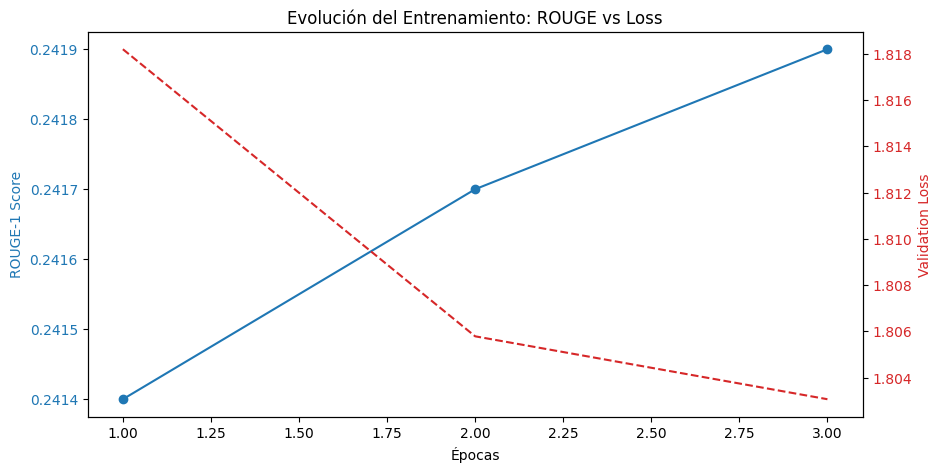

In [25]:
import matplotlib.pyplot as plt

# Extraer el historial de entrenamiento
history = trainer.state.log_history

# Filtrar las métricas de evaluación
eval_logs = [x for x in history if 'eval_rouge1' in x]

# Si has entrenado al menos una época completa, podrás graficar
if len(eval_logs) > 0:
    epochs = [x['epoch'] for x in eval_logs]
    rouge1 = [x['eval_rouge1'] for x in eval_logs]
    loss = [x['eval_loss'] for x in eval_logs]

    # Crear gráfica
    fig, ax1 = plt.subplots(figsize=(10, 5))

    # Eje izquierdo: ROUGE
    color = 'tab:blue'
    ax1.set_xlabel('Épocas')
    ax1.set_ylabel('ROUGE-1 Score', color=color)
    ax1.plot(epochs, rouge1, color=color, marker='o', label='Calidad Resumen (ROUGE)')
    ax1.tick_params(axis='y', labelcolor=color)

    # Eje derecho: LOSS
    ax2 = ax1.twinx()
    color = 'tab:red'
    ax2.set_ylabel('Validation Loss', color=color)
    ax2.plot(epochs, loss, color=color, linestyle='--', label='Error (Loss)')
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title('Evolución del Entrenamiento: ROUGE vs Loss')
    plt.show()
else:
    print("No hay suficientes datos de evaluación para graficar (¿quizás solo entrenaste 1 época?)")

En cuanto al **Validation Loss** (línea roja), observamos una tendencia claramente decreciente durante las tres épocas (bajando de ~1.818 a ~1.803). Esto confirma que el modelo sigue aprendiendo y optimizando su función de coste, reduciendo el error en sus predicciones sin mostrar signos de overfitting (si los hubiera, la línea roja habría empezado a subir).

Por otro lado, el **ROUGE-1 Score** (línea azul) muestra un crecimiento importante entre la época 1 y la 2, alcanzando su valor máximo de 0.2418. Lo destacable en esta gráfica es que, durante la época 3, el rendimiento se estabiliza y se mantiene en ese máximo, sin sufrir degradación. Esto indica una convergencia robusta: el modelo alcanzó su capacidad óptima de resumen rápidamente y logró sostenerla mientras continuaba puliendo su error interno (Loss).

Una vez hemos observado la gráfica, vamos a realizar la inferencia y ver como el modelo hace los resumenes. Así que vamos a coger un ejemplo de test y vamos a realizar el resumen del artículo.

In [33]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

# 3. Bucle para generar los 3 primeros resúmenes
for idx in range(3):
    # Extraer texto y resumen real
    input_text = small_test_dataset[idx]["article"]
    target_text = small_test_dataset[idx]["highlights"]

    # Tokenizar y mover a GPU
    input_ids = tokenizer("summarize: " + input_text, return_tensors="pt").input_ids.to(device)

    # Generar resumen
    outputs = model.generate(input_ids, max_length=128)
    generated_summary = tokenizer.decode(outputs[0], skip_special_tokens=True)

    # Mostrar resultados
    print(f"\n{'='*20} EJEMPLO {idx} {'='*20}")
    print("--- ARTÍCULO ORIGINAL (Inicio) ---")
    print(input_text)
    print("\n--- RESUMEN HUMANO (Real) ---")
    print(target_text)
    print("\n--- RESUMEN GENERADO MI TU MODELO ---")
    print(generated_summary)
    print("="*50)


==================== EJEMPLO 0 ====================
--- ARTÍCULO ORIGINAL (Inicio) ---
(CNN) I see signs of a revolution everywhere. I see it in the op-ed pages of the newspapers, and on the state ballots in nearly half the country. I see it in politicians who once preferred to play it safe with this explosive issue but are now willing to stake their political futures on it. I see the revolution in the eyes of sterling scientists, previously reluctant to dip a toe into this heavily stigmatized world, who are diving in head first. I see it in the new surgeon general who cites data showing just how helpful it can be. I see a revolution in the attitudes of everyday Americans. For the first time a majority, 53%, favor its legalization, with 77% supporting it for medical purposes. Support for legalization has risen 11 points in the past few years alone. In 1969, the first time Pew asked the question about legalization, only 12% of the nation was in favor. I see a revolution that is burning

1. **Puntos fuertes**:
- **Captura de entidades y datos**: el modelo demuestra una gran capacidad para extraer información factual precisa en múltiples contextos. Identifica lugares ("Memphis", "Kenilworth Town Hall"), plataformas ("Twitter"), protagonistas ("Chris Christie", "Kathy Mooney") y cifras financieras complejas ("$225million"). Esto demuestra que no está alucinando, sino estrayendo información precisa.
- **Contextualización narrativa**: en los casos exitosos (Ejemplo 2), el modelo captura el tono del artículo mejor que el resumen humano, aportando contexto (como la acusación de "bully") en lugar de listar solo los hechos cronológicos. En el Ejemplo 1, logra sintetizar bien la premisa del niño y su fama en redes.

2. **Problemas**:
- **Repetición y bucles**: Este es un fallo crítico observado en el Ejemplo 0 y levemente en el Ejemplo 1. El modelo tiende a entrar en bucles repetitivos ("...revolution in the world, and it's a revolution in the world...") o a repetir estructuras de frases ("In others... In others..."). Esto indica que el modelo necesita ajustes en los parámetros de penalización por repetición (`repetition_penalty`) o una mejor búsqueda de haces (*beam search*).
- El resumen del Ejemplo 2 termina abruptamente ("...Mooney said Mooney was 'fa") debido a que la generación alcanzó el límite de tokens (`max_length=128`) antes de cerrar la idea semántica.
- **Comparación contra humano**: Mientras el humano sintetiza la "idea central" (el mensaje de Sanjay Gupta o la conclusión del video), el modelo a veces se pierde en la narrativa o falla en la cohesión global (especialmente visible en el fallo del Ejemplo 0), mostrando un comportamiento más extractivo que abstractivo en ocasiones.

# Conclusiones

En este proyecto se ha implementado y evaluado el ajuste fino (*fine-tuning*) del modelo **T5-small** para la tarea de resumen abstractivo de noticias, utilizando el dataset **CNN/DailyMail**. A partir de los resultados cuantitativos y cualitativos obtenidos, se extraen las siguientes conclusiones:
- **Arquitectura clave**: se confirma que la arquitectura Encoder-Decoder (Seq2Seq) resulta más adecuada para tareas de generación condicional en comparación con modelos de solo codificador (como BERT). El modelo T5 ha demostrado capacidad no solo para comprender el texto de entrada, sino para reescribirlo generando oraciones nuevas con coherencia gramatical.
- **Rendimiento y convergencia**: el entrenamiento ha sido estable y exitoso. La función de pérdida de validación disminuyó constantemente hasta ~1.803 sin mostrar signos de sobreajuste.
La métrica **ROUGE-1** alcanzó un pico de 0.2419 y se estabilizó, lo que indica que el modelo aprendió rápidamente las características principales de la tarea de resumen con solo 1.000 ejemplos de entrenamiento.
- **Capacidad de abstracción**: el análisis cualitativo demuestra que el modelo logra capturar entidades complejas (nombres, lugares y cifras) y contextualizar la información de manera más efectiva que el resumen extractivo humano.

Se han detectado una serie de limitaciones como:
- **Longitud de generación**: se observó que los resúmenes generados tienden a cortarse abruptamente. Esto indica que el hiperparámetro `max_length=128` limitan la finalización natural de las oraciones en resúmenes densos.
- **Datos**: aunque los resultados son prometedores, el uso de un subconjunto reducido limita la capacidad del modelo para generalizar a vocabularios menos frecuentes.

En cuanto a los trabajos futuros, para mejorar los resultados, se propone:
- Aumentar el tamaño del dataset de entrenamiento para exponer al modelo a una mayor diversidad lingüística.
- Implementar *Beam Search* durante la inferencia para mejorar la calidad de las oraciones generadas.
- Ajustar los parámetros de penalización de longitud para favorecer resúmenes completos que no se corten a mitad de frase.